In [1]:
import gaiaDR4_pipeline as gp
from pathlib import Path
from tqdm import tqdm 
import os
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
cwd = Path(os.getcwd()) / "dr4_prerelease"

In [3]:
# Read the XML table
table = Table.read(cwd / "GAIA_DR4_PRERELEASE_EPOCH_ASTROMETRY_RAW.xml", format="votable")
df_data = table.to_pandas()

In [4]:
#sourceIDs = find_file(tag="SingleStar_M035", sourceID_only=True)
source_ids = [ 1457486023639239296,  3937211745905473024]
mstars = [0.74, 1.046]

In [7]:
arrayID = 1

source_id = source_ids[arrayID]
mstar = mstars[arrayID]

t_binned, psi_binned, w_binned, sig_w_binned, pf_binned = gp.utils.extract_time_series(source_id, df_data)
ra, dec = gp.utils.extract_ra_dec(source_id, df_data)

jobID = 0
gp.mcmc.run_pipeline(cwd, jobID, source_id, t_binned, w_binned, sig_w_binned, pf_binned, psi_binned, mstar, in_notebook=True)

Starting run 0...
RUWE: 3.4835710081302005
Building single star model...
Building planet-star model...

Fitting Single Star Model...


Initializing NUTS using adapt_full...
/u/nm78/miniconda3/envs/delta_env/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [delta_ra, delta_dec, pm_ra, pm_dec, log_parallax]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Output()

...


DETAILED COMPARISON (using az.compare):


/u/nm78/miniconda3/envs/delta_env/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/u/nm78/miniconda3/envs/delta_env/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/u/nm78/miniconda3/envs/delta_env/lib/py

             rank     elpd_loo       p_loo    elpd_diff  weight          se  \
Planet_Star     0   557.439297   21.058522     0.000000     1.0   39.046948   
Single_Star     1 -3089.890290  435.605314  3647.329586     0.0  487.561751   

                    dse  warning scale  
Planet_Star    0.000000     True   log  
Single_Star  474.619706     True   log  


/u/nm78/miniconda3/envs/delta_env/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



------------------------------------------------------------
MODEL COMPARISON SUMMARY
------------------------------------------------------------
Single Star Model ELPD: -3089.89 ± 487.56
Planet-Star Model ELPD: 557.44 ± 39.05
Difference (Binary - Single): 3647.33 ± 474.62
LOO SNR: 7.68474114840857

Saving results...
Pipeline runtime: 1.10 minutes
Binary model sampling time: 33.59 seconds
Pipeline run complete.


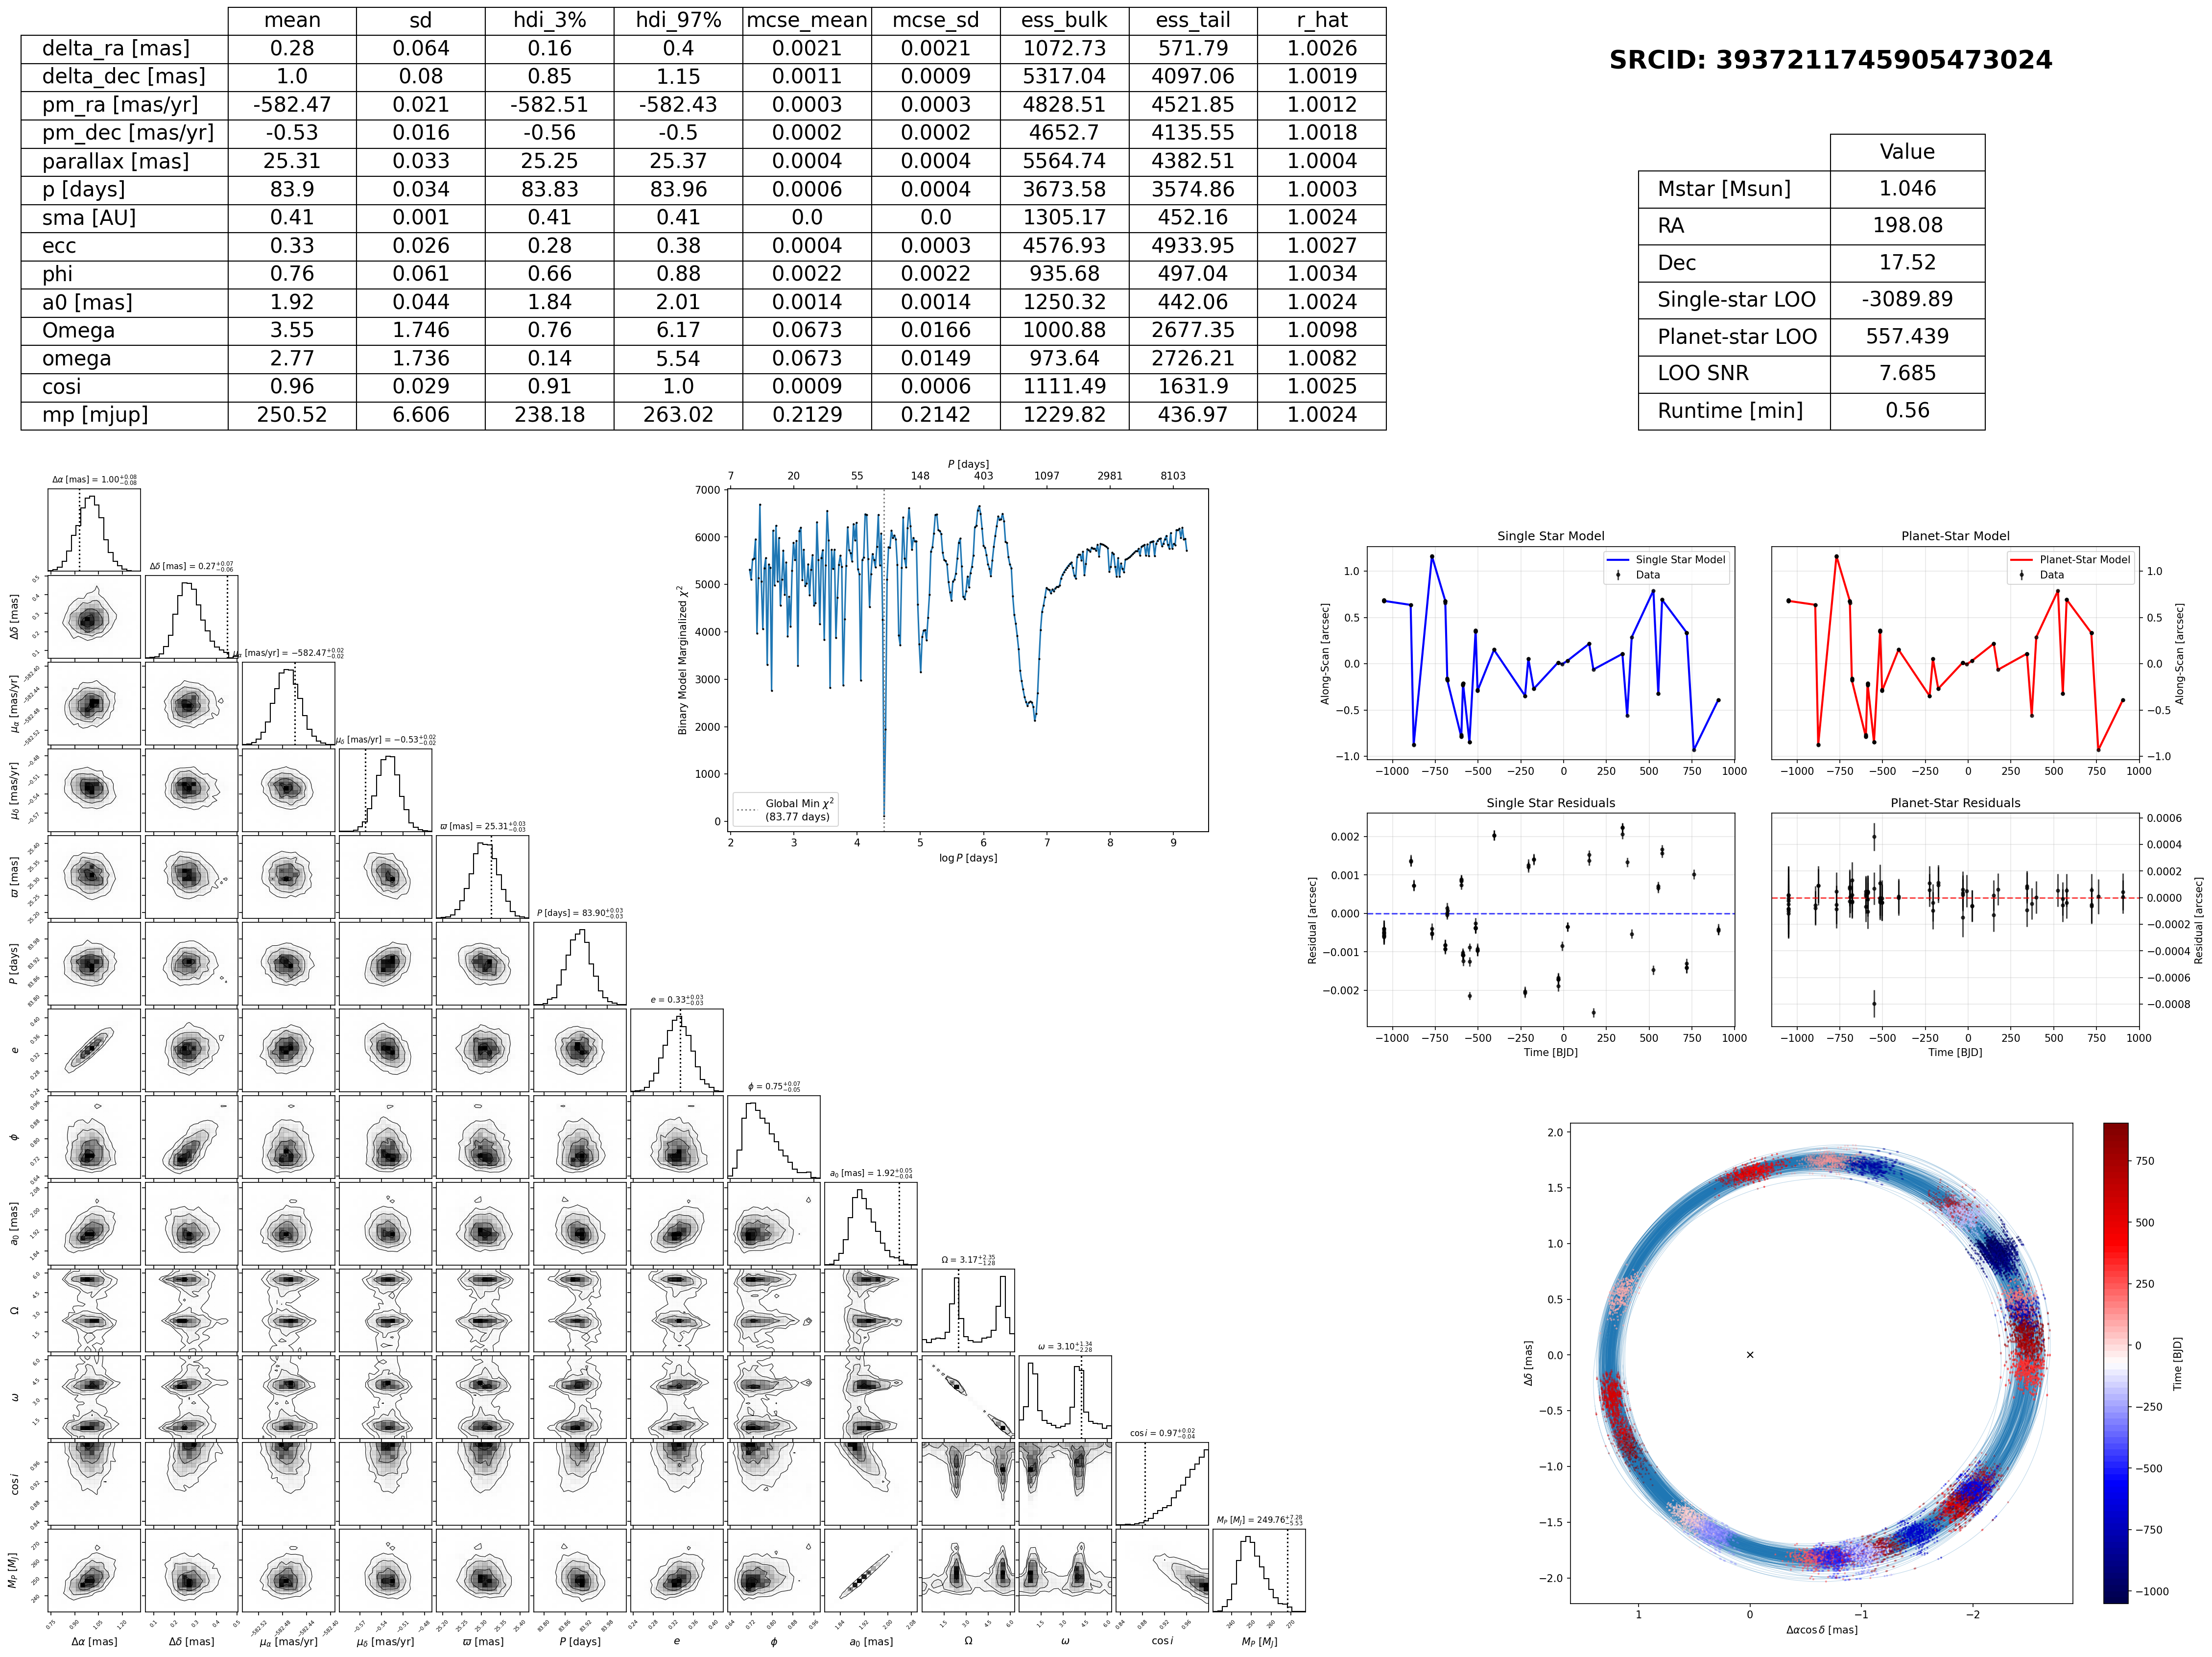

In [8]:
gp.plotting.summary_plot(cwd, source_id, jobID, mstar, ra, dec, t_binned, w_binned, sig_w_binned);

In [ ]:
plotting_dir = Path(cwd / "plots")
plotting_dir.mkdir(parents=True, exist_ok=True)

with PdfPages(plotting_dir / f"job{jobID}_summary.pdf") as pdf:
    for j, source_id in enumerate(tqdm(source_ids)):
        mstar = mstars[j]

        t_binned, psi_binned, w_binned, sig_w_binned, pf_binned = gp.utils.extract_time_series(source_id, df_data)
        ra, dec = gp.utils.extract_ra_dec(source_id, df_data)

        fig = gp.plotting.summary_plot(cwd, source_id, jobID, mstar, ra, dec, t_binned, w_binned, sig_w_binned)
        pdf.savefig(fig, dpi=30)
        plt.close(fig)

100%|██████████| 2/2 [00:24<00:00, 12.22s/it]
